In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
import os
from glob import glob

import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing

#### Initial data inspection

In [2]:
metadata = pd.read_csv('D:\skin\HAM10000_metadata.csv')

In [3]:
metadata

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern


In [4]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   dataset       10015 non-null  str    
dtypes: float64(1), str(7)
memory usage: 1.2 MB


In [5]:
metadata.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


#### Removing dupliacted rows and null values

In [6]:
metadata.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dataset          0
dtype: int64

In [7]:
metadata['age'] = metadata['age'].fillna(metadata['age'].mean(), inplace=True)

In [8]:
metadata.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dataset         0
dtype: int64

In [9]:
print(f'number of rows with 0 age vlaue: {metadata['age'].loc[metadata['age'] == 0].count()}')

number of rows with 0 age vlaue: 39


In [10]:
metadata.loc[metadata['age'] == 0, 'age'] = metadata['age'].mean()

In [11]:
print(f'number of rows with 0 age vlaue after clean up: {metadata['age'].loc[metadata['age'] == 0].count()}')

number of rows with 0 age vlaue after clean up: 0


In [12]:
metadata.duplicated().sum()

0

In [13]:
metadata.sex.value_counts()

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

In [14]:
condition = metadata.duplicated(subset="lesion_id")
print(f"Number of duplicated unique id's: {condition.sum()}")

Number of duplicated unique id's: 2545


In [15]:
metadata.loc[condition]

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face,vidir_modern
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back,vidir_modern
...,...,...,...,...,...,...,...,...
10009,HAM_0005705,ISIC_0031430,akiec,histo,75.0,female,lower extremity,vidir_modern
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,vidir_modern
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,vidir_modern
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,vidir_modern


### 🟢 Benign Lesions (Non-Cancerous)
* **nv (Melanocytic nevi):** Common moles. These are typically harmless growths of melanocytes (pigment-producing cells) that can be flat or raised.
* **bkl (Benign keratosis-like lesions):** Includes non-cancerous, wart-like, or "stuck-on" growths such as seborrheic keratosis.
* **df (Dermatofibroma):** Small, firm, benign bumps that form in the deeper layers of the skin, often appearing on the legs.
* **vasc (Vascular lesions):** Visible abnormalities of the blood vessels, such as cherry angiomas or spider veins.

### 🟡 Pre-Cancerous & Early Stages
* **akiec (Actinic keratoses / Bowen’s disease):** Scaly, rough, or crusty patches of skin caused by years of sun exposure. While actinic keratoses are precancerous, Bowen's disease is considered a very early, highly treatable form of skin cancer (squamous cell carcinoma in situ).

### 🔴 Malignant (Cancerous)
* **bcc (Basal cell carcinoma):** The most common type of skin cancer. These usually appear as pearly, waxy, or flesh-colored bumps, or sometimes as flat, scaly patches.
* **mel (Melanoma):** The most serious and aggressive form of skin cancer. Melanoma typically originates in melanocytes and is known to spread, making early detection critical.


#### Encoding

In [16]:
print(f"unique diagnosis: {list(metadata["dx"].unique())}")

unique diagnosis: ['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']


In [17]:
dx_map = {
    "nv": "Melanocytic nevi",
    "mel": "Melanoma",
    "bcc": "Basal cell carcinoma",
    "akiec": "Actinic keratoses / Bowen’s disease",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "vasc": "Vascular lesions"
}


metadata["cell_type"] = metadata["dx"].map(dx_map.get)

In [18]:
metadata["cell_type_ix"] = pd.Categorical(metadata["cell_type"]).codes

In [19]:
metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix
6674,HAM_0006535,ISIC_0032069,nv,follow_up,45.0,female,upper extremity,vidir_molemax,Melanocytic nevi,4
1284,HAM_0002534,ISIC_0024898,mel,histo,80.0,male,lower extremity,vidir_modern,Melanoma,5
4860,HAM_0003240,ISIC_0026387,nv,follow_up,65.0,female,lower extremity,vidir_molemax,Melanocytic nevi,4
4678,HAM_0003213,ISIC_0031747,nv,follow_up,50.0,female,trunk,vidir_molemax,Melanocytic nevi,4
5771,HAM_0004452,ISIC_0027381,nv,follow_up,35.0,male,trunk,vidir_molemax,Melanocytic nevi,4



##### dx_type (diagnosis confirmation)
- `histo` : Histopathology  
- `follow_up` : Follow-up examination  
- `consensus` : Expert consensus  
- `confocal` : Confocal microscopy

In [20]:
print(f"unique diagnosis confirmation: {list(metadata["dx_type"].unique())}")

unique diagnosis confirmation: ['histo', 'consensus', 'confocal', 'follow_up']


In [21]:
print(f"unique localizations: {list(metadata["localization"].unique())}")

unique localizations: ['scalp', 'ear', 'face', 'back', 'trunk', 'chest', 'upper extremity', 'abdomen', 'unknown', 'lower extremity', 'genital', 'neck', 'hand', 'foot', 'acral']


##### Meaning of Each Source

- **rosendahl**  
  Images contributed from the Rosendahl collection / clinic source.

- **vienna_dias**  
  Images from a Vienna dermatology source (often one of the Austrian contributors).

- **vidir_molemax**  
  Images captured using MoleMax system by VIDIR.

- **vidir_modern**  
  Images from newer / modern VIDIR acquisition devices.

In [22]:
print(f"unique datasets: {list(metadata["dataset"].unique())}")

unique datasets: ['vidir_modern', 'rosendahl', 'vienna_dias', 'vidir_molemax']


#### Adding images paths

In [23]:
data_dir = '../training'
all_images_path = glob(os.path.join(data_dir, '*', '*.jpg'))
imageid_dict = { os.path.splitext( os.path.basename(x))[0]: x for x in all_images_path }

In [24]:
metadata["path"] = metadata["image_id"].map(imageid_dict.get)

In [25]:
metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
1223,HAM_0006722,ISIC_0030443,mel,histo,85.0,female,lower extremity,vidir_modern,Melanoma,5,../training\HAM10000_images_part_2\ISIC_003044...
4281,HAM_0006642,ISIC_0030916,nv,follow_up,50.0,male,trunk,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003091...
6399,HAM_0007222,ISIC_0030996,nv,follow_up,45.0,male,trunk,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003099...
6944,HAM_0007606,ISIC_0025870,nv,histo,70.0,female,foot,vidir_modern,Melanocytic nevi,4,../training\HAM10000_images_part_1\ISIC_002587...
3657,HAM_0004818,ISIC_0030736,nv,follow_up,50.0,female,abdomen,vidir_molemax,Melanocytic nevi,4,../training\HAM10000_images_part_2\ISIC_003073...


image shape: (450, 600, 3)


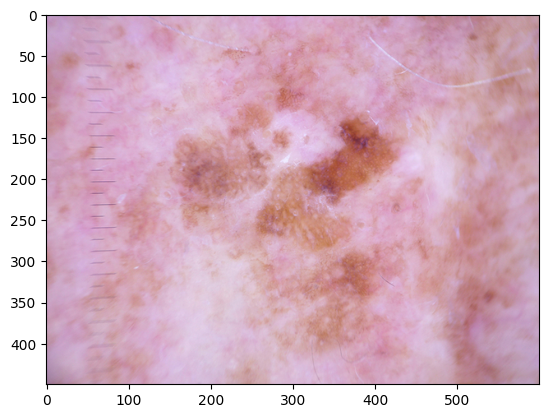

In [26]:
img = cv.imread(metadata.head(1)["path"].values[0])
print(f"image shape: {img.shape}")
plt.imshow(img[:, :, ::-1])

In [27]:
metadata.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dataset         0
cell_type       0
cell_type_ix    0
path            0
dtype: int64

In [28]:
eda_condition = metadata.duplicated(subset="lesion_id")

In [29]:
eda_df = metadata.loc[~eda_condition]
eda_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002741...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002676...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_2\ISIC_003163...
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002917...
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002583...
...,...,...,...,...,...,...,...,...,...,...,...
9994,HAM_0000193,ISIC_0030877,akiec,histo,60.0,female,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003087...
10001,HAM_0000020,ISIC_0031922,akiec,histo,60.0,female,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003192...
10004,HAM_0005579,ISIC_0029309,akiec,histo,80.0,male,face,rosendahl,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_002930...
10008,HAM_0001576,ISIC_0033705,akiec,histo,60.0,male,face,vidir_modern,Actinic keratoses / Bowen’s disease,0,../training\HAM10000_images_part_2\ISIC_003370...


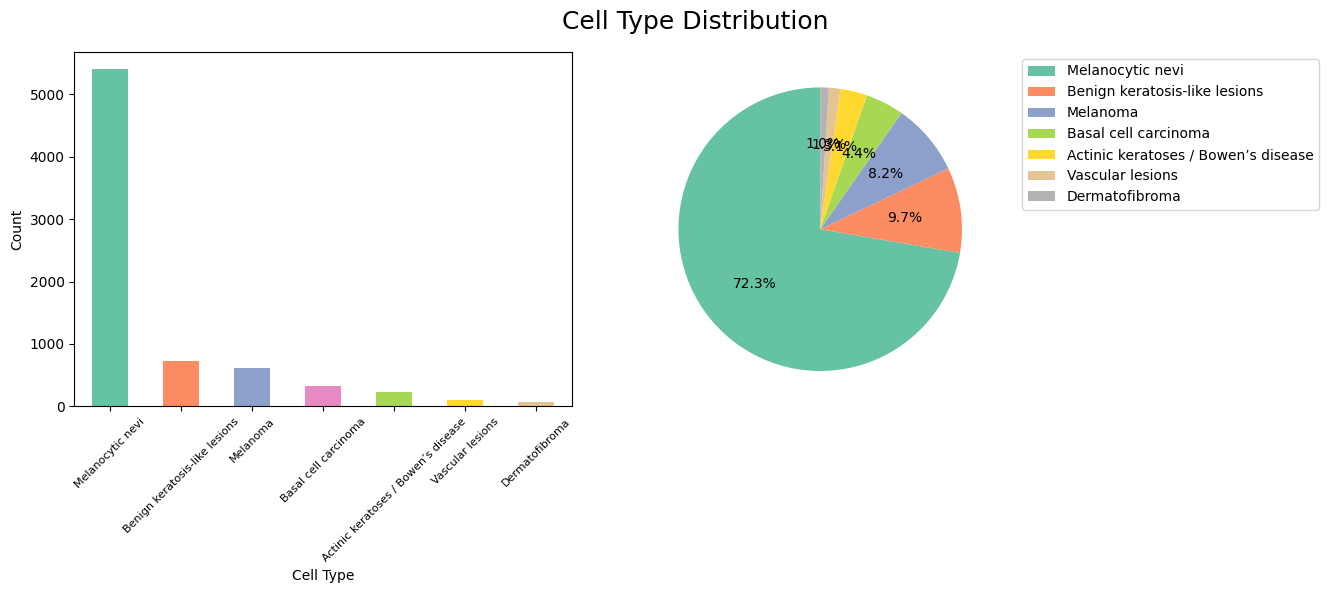

In [30]:
cell_counts = eda_df["cell_type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = sns.color_palette("Set2", len(cell_counts))

# Bar chart
cell_counts.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_xlabel("Cell Type")
axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45
)
axes[0].tick_params(axis='x', labelsize=8)
axes[0].set_ylabel("Count")

# Pie chart
cell_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colormap="Set2",
    labels=None,
)

plt.legend(cell_counts.index, fontsize=10, bbox_to_anchor=(1.05, 1))
plt.suptitle("Cell Type Distribution", fontsize=18)
plt.ylabel("")
plt.tight_layout()
plt.show()

# Test Dataset Preprocessing

#### Initial data inspection

In [46]:
test_metadata = pd.read_csv('D:\skin\ISIC2018_Task3_Test_GroundTruth.csv')

In [47]:
test_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     1512 non-null   str    
 1   image_id      1512 non-null   str    
 2   dx            1512 non-null   str    
 3   dx_type       1512 non-null   str    
 4   age           1230 non-null   float64
 5   sex           1511 non-null   str    
 6   localization  1511 non-null   str    
 7   dataset       1511 non-null   str    
dtypes: float64(1), str(7)
memory usage: 184.4 KB


In [48]:
test_data_dir = '../ISIC2018_Task3_Test_Images'
all_test_images_path = glob(os.path.join(test_data_dir, '*', '*.jpg'))
test_imageid_dict = { os.path.splitext( os.path.basename(x))[0]: x for x in all_test_images_path }

In [49]:
test_metadata["path"] = test_metadata["image_id"].map(test_imageid_dict.get)

In [50]:
test_metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,path
1313,HAMTEST_0001097,ISIC_0035866,bkl,histo,40.0,female,face,vidir_modern,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
559,HAMTEST_0000519,ISIC_0035094,nv,histo,35.0,female,foot,rosendahl,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
399,HAMTEST_0000377,ISIC_0034930,bkl,consensus,NaN,unknown,unknown,external,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
693,HAMTEST_0000632,ISIC_0035233,nv,follow_up,65.0,male,lower extremity,vidir_molemax,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...
1038,HAMTEST_0000192,ISIC_0035589,bkl,histo,45.0,male,upper extremity,vidir_modern,../ISIC2018_Task3_Test_Images\ISIC2018_Task3_T...


# U-Net Segmentation

In [31]:
mask_data_dir = '../HAM10000_segmentations_lesion_tschandl'
all_masks_path = glob(os.path.join(mask_data_dir, '*', '*.png'))
mask_id_dict = { os.path.splitext( os.path.basename(x))[0]: x for x in all_masks_path }

In [32]:
next(iter(mask_id_dict))

'ISIC_0024306_segmentation'

In [33]:
for key in list(mask_id_dict):
    if "_segmentation" in key:
        new_key = key.replace("_segmentation", "")
        mask_id_dict[new_key] = mask_id_dict.pop(key)


In [34]:
next(iter(mask_id_dict))

'ISIC_0024306'

In [35]:
metadata["mask_path"] = metadata["image_id"].map(mask_id_dict.get)

In [36]:
metadata.head(1)

,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,cell_type,cell_type_ix,path,mask_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,Benign keratosis-like lesions,2,../training\HAM10000_images_part_1\ISIC_002741...,../HAM10000_segmentations_lesion_tschandl\HAM1...


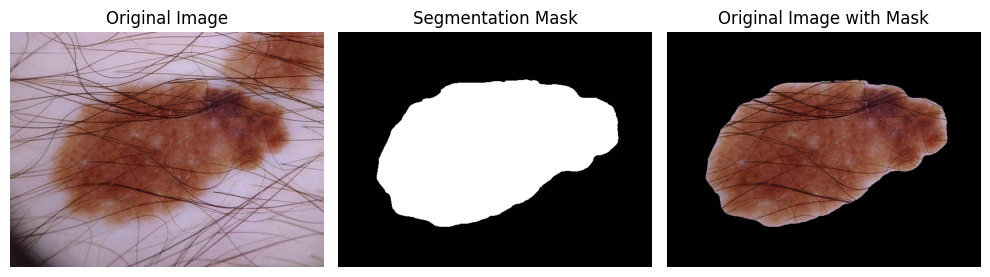

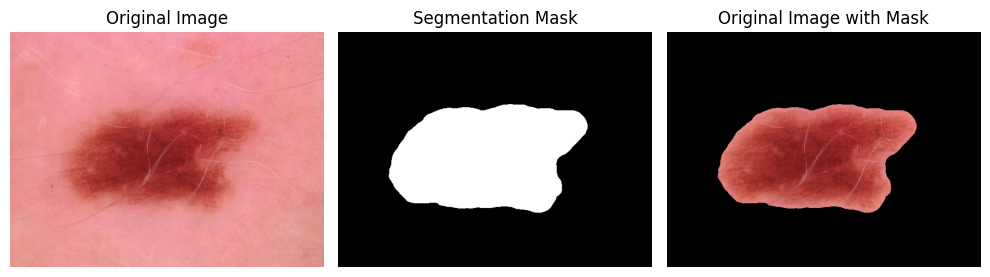

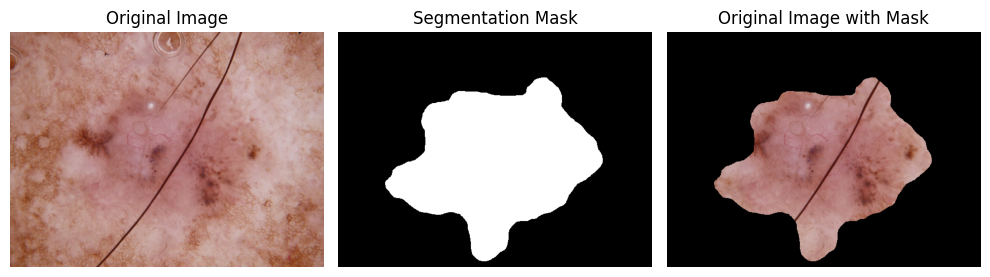

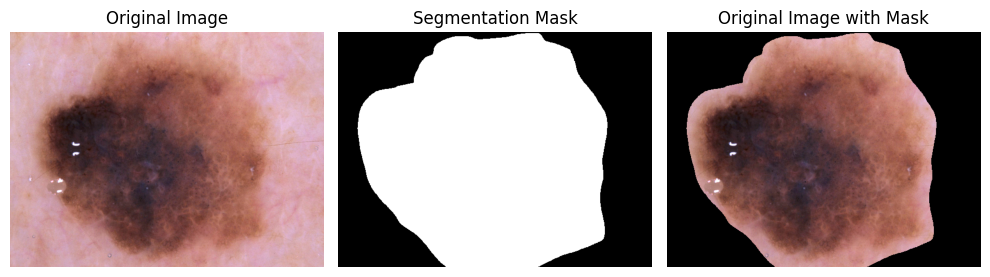

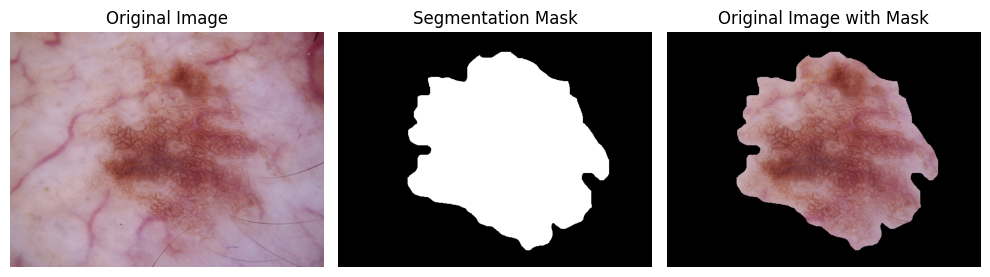

In [37]:
sample_df = metadata.sample(5)

for _, row in sample_df.iterrows():
    img = cv.imread(row["path"])
    mask = cv.imread(row["mask_path"], cv.IMREAD_GRAYSCALE)
    img_masked = cv.bitwise_and(img, img, mask=mask)

    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    axes[0].imshow(img[:, :, ::-1])
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    axes[2].imshow(img_masked[:, :, ::-1])
    axes[2].set_title("Original Image with Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [38]:
IMG_SIZE = 128

images = []
masks = []

for _, row in metadata.iterrows():

    # IMAGE
    img = cv.imread(row["path"])
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    # MASK
    mask = cv.imread(
        row["mask_path"],
        cv.IMREAD_GRAYSCALE
    )

    mask = cv.resize(mask, (IMG_SIZE, IMG_SIZE))

    # binary mask
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)

    images.append(img)
    masks.append(mask)

X = np.array(images, dtype=np.float32)
y = np.array(masks, dtype=np.float32)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
print(f"Training set - X: {X_train.shape}, y: {y_train.shape}")

print(f"\nTesting set - X: {X_test.shape}, y: {y_test.shape}")

Training set - X: (8012, 128, 128, 3), y: (8012, 128, 128, 1)

Testing set - X: (2003, 128, 128, 3), y: (2003, 128, 128, 1)


In [41]:
import tensorflow as tf
from tensorflow.keras import layers, Model

In [42]:
def conv_block(x, filters):

    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)

    return x

In [43]:
inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))


c1 = conv_block(inputs, 64)
p1 = layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 128)
p2 = layers.MaxPooling2D()(c2)

c3 = conv_block(p2, 256)
p3 = layers.MaxPooling2D()(c3)

# Bottleneck
bn = conv_block(p3, 512)

# Decoder
u1 = layers.UpSampling2D()(bn)
u1 = layers.concatenate([u1, c3])
c4 = conv_block(u1, 256)

u2 = layers.UpSampling2D()(c4)
u2 = layers.concatenate([u2, c2])
c5 = conv_block(u2, 128)

u3 = layers.UpSampling2D()(c5)
u3 = layers.concatenate([u3, c1])
c6 = conv_block(u3, 64)

outputs = layers.Conv2D(
    1,
    1,
    activation="sigmoid"
)(c6)

model = Model(inputs, outputs)

In [44]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=6,
    batch_size=32
)

Epoch 1/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 3766s 17s/step - accuracy: 0.8740 - loss: 0.3110 - val_accuracy: 0.9223 - val_loss: 0.2068
Epoch 2/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 4013s 18s/step - accuracy: 0.9300 - loss: 0.1784 - val_accuracy: 0.9399 - val_loss: 0.1504
Epoch 3/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 2833s 13s/step - accuracy: 0.9428 - loss: 0.1431 - val_accuracy: 0.9493 - val_loss: 0.1228
Epoch 4/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 2554s 11s/step - accuracy: 0.9463 - loss: 0.1330 - val_accuracy: 0.9440 - val_loss: 0.1444
Epoch 5/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 2079s 9s/step - accuracy: 0.9485 - loss: 0.1278 - val_accuracy: 0.9528 - val_loss: 0.1138
Epoch 6/6
226/226 ━━━━━━━━━━━━━━━━━━━━ 2339s 10s/step - accuracy: 0.9513 - loss: 0.1191 - val_accuracy: 0.9488 - val_loss: 0.1227


In [83]:
all_images = []
all_preds = []

for path in test_metadata["path"].dropna().astype(str):

    image = cv.imread(path)
    image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

    image = cv.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    all_images.append(image)

all_images = np.array(all_images)

preds = model.predict(all_images)

print(all_images.shape)
print(preds.shape)

48/48 ━━━━━━━━━━━━━━━━━━━━ 308s 6s/step
(1511, 128, 128, 3)
(1511, 128, 128, 1)


In [84]:
mask_03 = (preds > 0.3).astype(np.uint8)
mask_05 = (preds > 0.5).astype(np.uint8)
mask_07 = (preds > 0.7).astype(np.uint8)

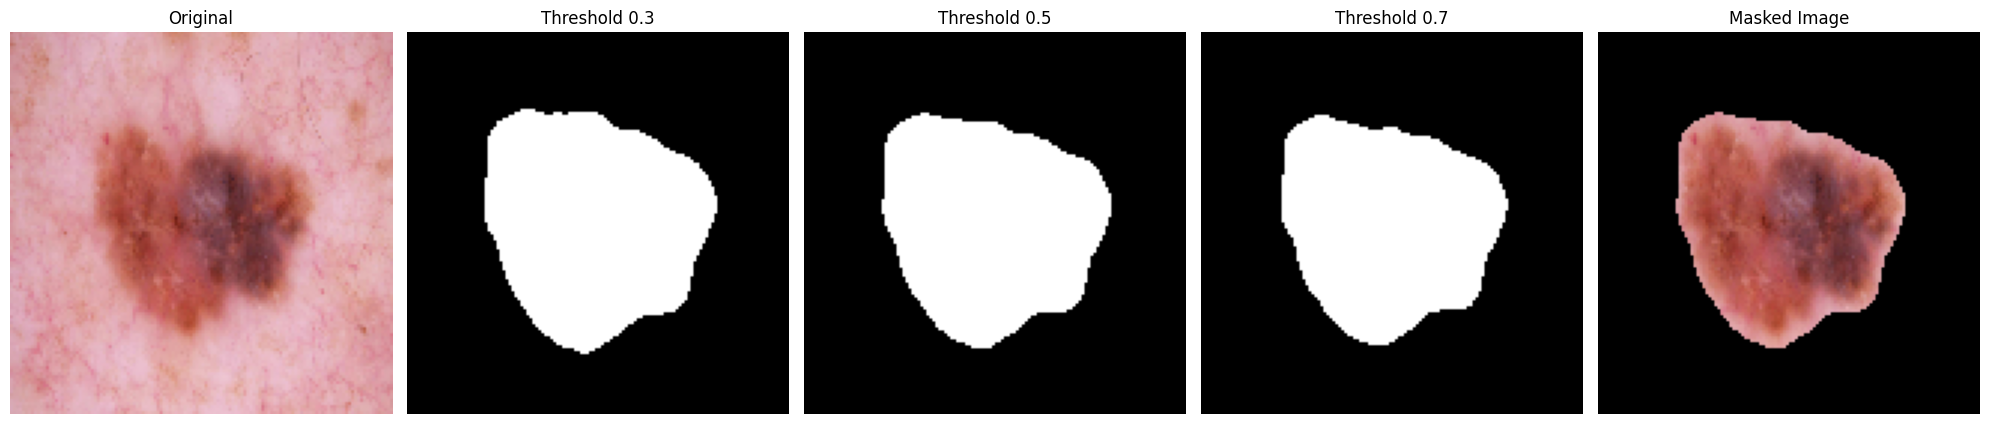

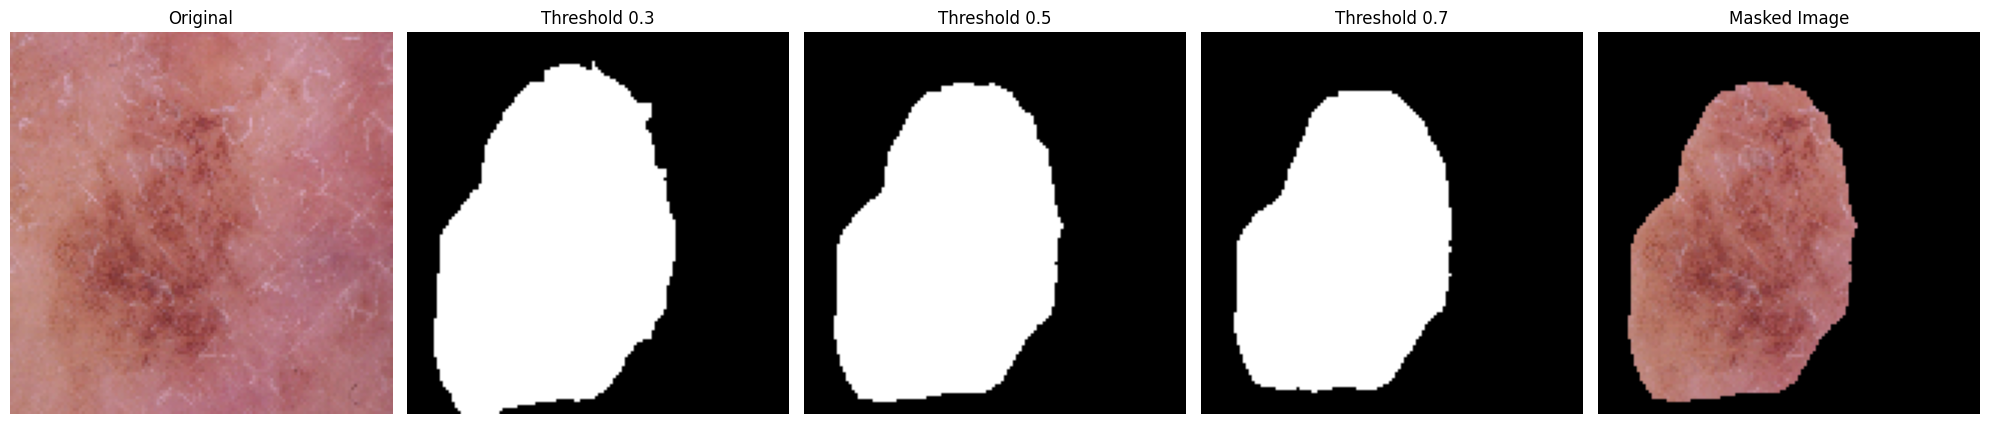

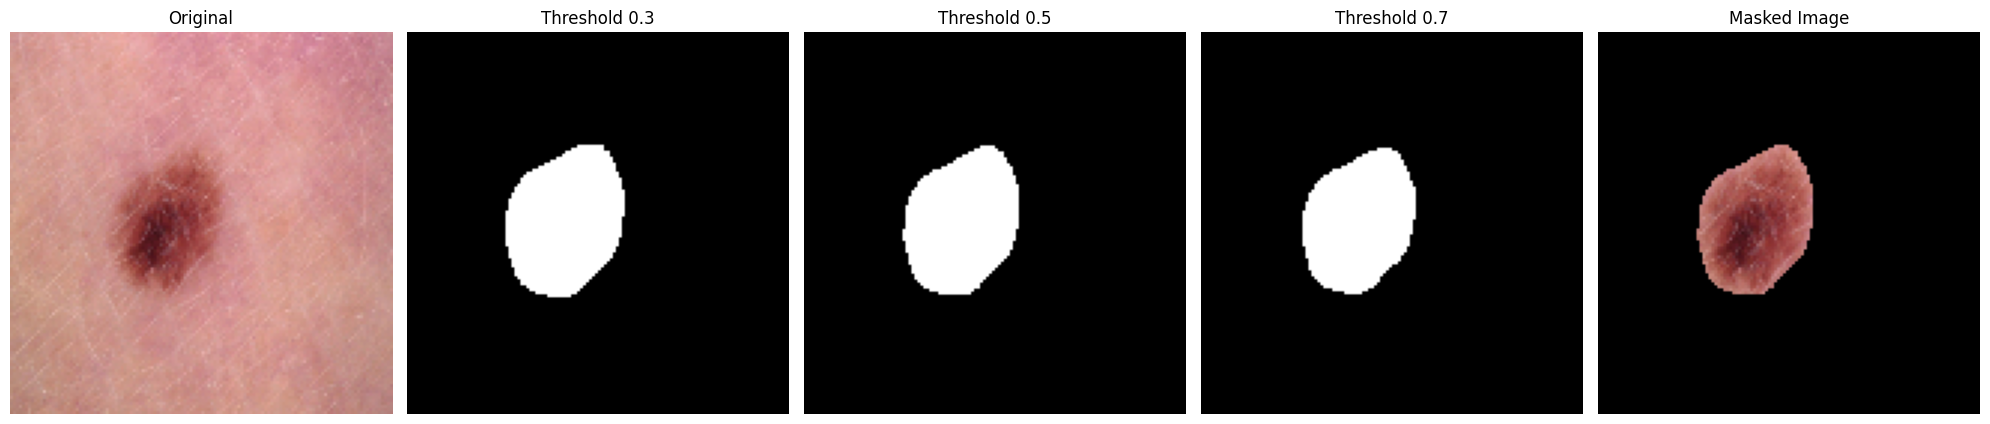

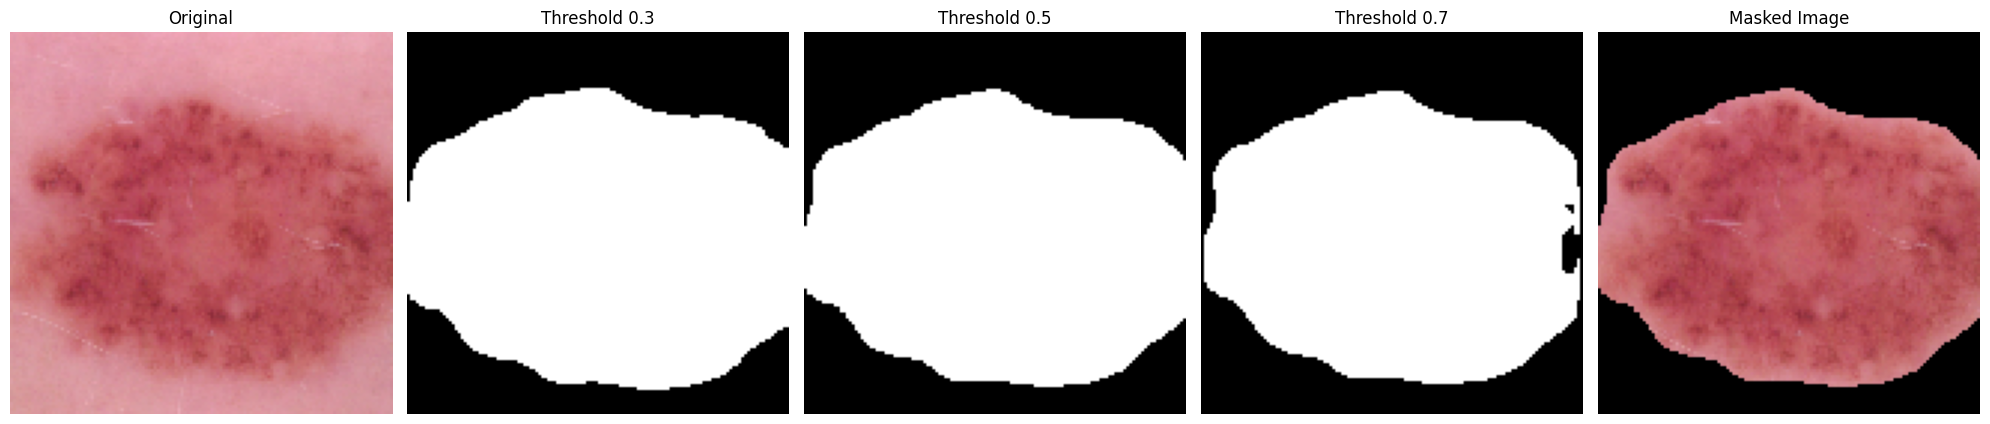

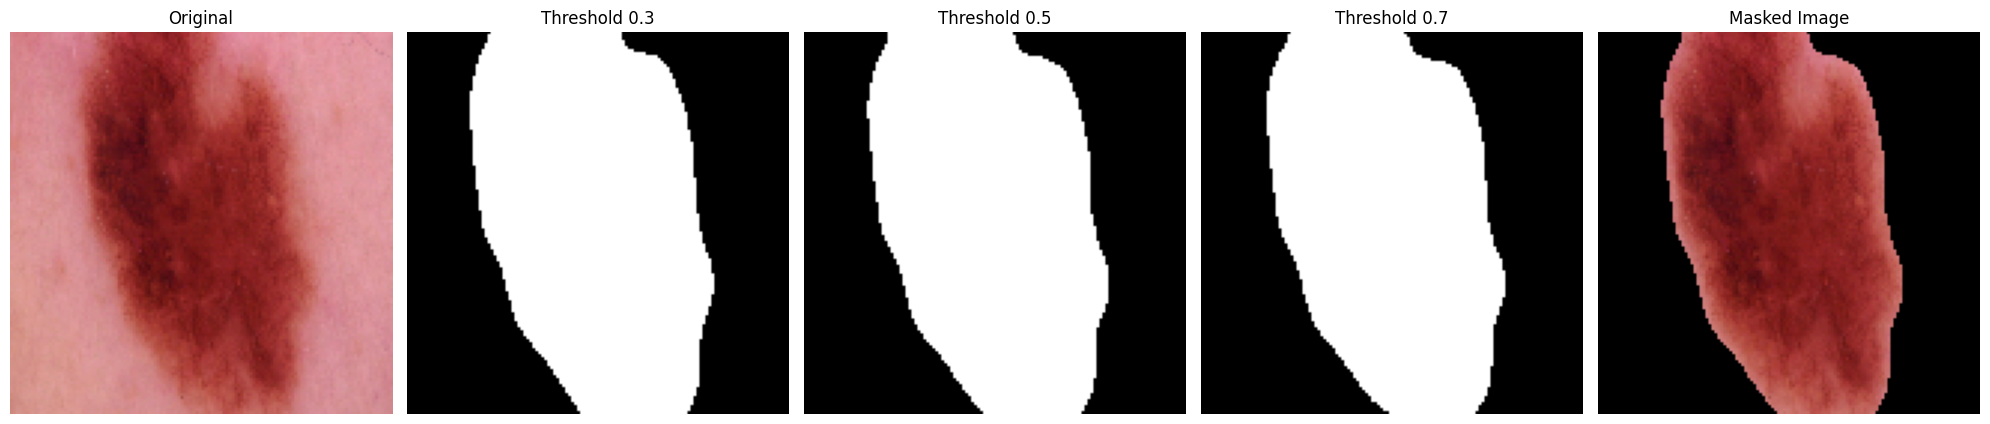

In [85]:
import random


indices = random.sample(range(len(all_images)), 5)

for idx in indices:

    image = all_images[idx]
    pred = preds[idx, :, :, 0]

    mask_03 = (pred > 0.3).astype(np.uint8)
    mask_05 = (pred > 0.5).astype(np.uint8)
    mask_07 = (pred > 0.7).astype(np.uint8)

    masked_image = image.copy()
    masked_image[mask_05 == 0] = 0

    plt.figure(figsize=(20,5))

    # Original
    plt.subplot(1,5,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    # Threshold 0.3
    plt.subplot(1,5,2)
    plt.imshow(mask_03, cmap="gray")
    plt.title("Threshold 0.3")
    plt.axis("off")

    # Threshold 0.5
    plt.subplot(1,5,3)
    plt.imshow(mask_05, cmap="gray")
    plt.title("Threshold 0.5")
    plt.axis("off")

    # Threshold 0.7
    plt.subplot(1,5,4)
    plt.imshow(mask_07, cmap="gray")
    plt.title("Threshold 0.7")
    plt.axis("off")

    # Masked image
    plt.subplot(1,5,5)
    plt.imshow(masked_image)
    plt.title("Masked Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()